# Tech Challenge Fase 3 — Análise Exploratória de Dados (EDA)

Este é o **primeiro** notebook da Fase 3. EDA quer dizer: **olhar os dados com método antes de treinar qualquer modelo**. Sem isso, é fácil construir um classificador que “acerta” porque está lendo o gabarito, ou que prevê aluno alfabetizado numa tabela em que **não existe aluno**.

Se você não é da área de dados, cada gráfico abaixo responde a uma pergunta em português. Os códigos geram o gráfico; a pergunta e a conclusão é o que entra no relatório.

---

## Em uma frase

A tabela não é “cada linha = uma criança”. Cada linha é **a rede municipal de um município em um ano (2023 ou 2024)**. A taxa de alfabetização já vem **agregada** (0 a 100%). O corte 743 pontos é da prova do aluno no SAEB — **não se aplica** a esta coluna.

---

## O que este notebook precisa decidir para os próximos

1. Qual é a **unidade** (município-ano vs aluno)?
2. Como está a alfabetização no Brasil desta amostra (média, extremos, regiões)?
3. Quais colunas **são o resultado** (não podem entrar no modelo) e quais são **contexto** (podem)?
4. Onde estão os **buracos** (valores faltantes) — aleatórios ou um ano inteiro sem informação?

Os notebooks 02 e 03 **não reinventam** essas respostas; eles implementam.

---

## Como ler os gráficos (mini-glossário)

- **Histograma:** “em quantos municípios a taxa cai nesta faixa?”. Pico à direita = muitos com taxa alta.
- **Boxplot (caixa):** o traço do meio é a mediana (metade abaixo, metade acima). A caixa é o meio da turma. Pontos longe são extremos, não necessariamente erro.
- **Correlação (r):** de −1 a +1. Perto de **+1** = as duas colunas sobem juntas (quase a mesma informação). Perto de **0** = uma não conta a outra. Perto de **−1** = uma sobe quando a outra desce.
- **Univariada:** uma coluna sozinha. **Bivariada:** duas colunas juntas (em geral cruzando com a taxa).

---

## Índice

1. Importação de bibliotecas  
2. Carregamento dos dados  
3. Visão geral  
4. Análise univariada  
5. Análise bivariada  
6. Correlações (visão ampla)  
7. Valores faltantes  
8. Insights e conclusões (o que muda no modelo)


## 1. Importação de bibliotecas

Ferramentas de tabela (`pandas`), cálculo (`numpy`) e gráfico (`matplotlib`, `seaborn`). Nada disto ainda é “inteligência artificial” — é planilha e desenho, em escala.


In [71]:
# Manipulação de dados
import sys
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing.silver_schema import load_silver_table

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configurações
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento dos dados

Na Fase 2 os dados saíram do INEP e foram organizados em camadas (Bronze bruto, Silver limpo, Gold analítico). Aqui lemos o **Silver** `indicador_alfabetizacao`: a tabela municipal já consolidada.

Os arquivos estão particionados por ano (`ano=` ou `year=` do pipeline). O loader junta os pedaços e traduz colunas em inglês (`literacy_rate`) para o schema dos notebooks (`taxa_alfabetizacao`). Se a leitura falhar: rode `python pipelines/export_silver_fase3.py` ou confira `data/silver/`.

**O que você deve ver depois:** da ordem de **10 mil linhas**, dezenas de colunas, dois anos. Não espere milhões de linhas de aluno — esse microdado **não está** neste repositório.


In [72]:
# Definir caminhos
gold_path = Path('../data/gold')
silver_path = Path('../data/silver')

# Listar tabelas disponíveis (pastas podem não existir até o export do Silver)
print("📂 Tabelas disponíveis:")
print("\nGold (dados analíticos):")
if gold_path.exists():
    for table in gold_path.iterdir():
        if table.is_dir():
            print(f"   - {table.name}")
else:
    print("   (pasta ausente)")

print("\nSilver (dados integrados):")
if silver_path.exists():
    for table in silver_path.iterdir():
        if table.is_dir():
            print(f"   - {table.name}")
else:
    print("   (pasta ausente — o loader também procura output/silver da Fase 2)")

# Silver em português (indicador_alfabetizacao) ou inglês da Fase 2 (literacy_indicator)
df, data_path = load_silver_table(silver_path)
print(f"\n📊 Carregando dados Silver: {data_path}")

print(f"\n✅ Dataset carregado: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"   Municípios distintos: {df['id_municipio'].nunique():,}" if 'id_municipio' in df.columns else '')
print(f"   Regiões: {df['regiao'].nunique()} | UFs: {df['nome_uf'].nunique()}" if {'regiao', 'nome_uf'} <= set(df.columns) else '')

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

📂 Tabelas disponíveis:

Gold (dados analíticos):
   - indicador_municipio
   - meta_vs_resultado
   - evolucao_temporal

Silver (dados integrados):
   - indicador_alfabetizacao

📊 Carregando dados: indicador_alfabetizacao (camada Silver)
   Encontrados 49 arquivos particionados

✅ Dataset carregado: 10,896 linhas x 44 colunas
   Municípios distintos: 5,500
   Regiões: 5 | UFs: 25


## 3. Visão geral dos dados

As próximas células são o “abrir a planilha”:

- **Primeiras linhas** — um gostinho dos nomes das colunas (`taxa_alfabetizacao`, `regiao`, `meta_municipio_...`).
- **Info** — tipo de cada coluna (número vs texto) e se há nulos.
- **Estatísticas** — média, mínimo, máximo das colunas numéricas. A taxa deve viver entre 0 e 100; se a média aparecer na casa dos 700, você está olhando escala SAEB por engano.
- **Lista de colunas** — o mapa do que existe. IDs (`id_municipio`, `nome_municipio`) identificam a cidade; não são “causas” da alfabetização.


In [73]:
# Primeiras linhas
print("🔍 Primeiras 5 linhas do dataset:")
df.head()

🔍 Primeiras 5 linhas do dataset:


,id_municipio,taxa_alfabetizacao,media_portugues,fonte,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8,nome_municipio,nome_uf,regiao,meta_municipio_taxa_base,meta_municipio_percentual_participacao,meta_municipio_nivel_alfabetizacao,meta_municipio_alfabetizacao_2024,meta_municipio_alfabetizacao_2025,meta_municipio_alfabetizacao_2026,meta_municipio_alfabetizacao_2027,meta_municipio_alfabetizacao_2028,meta_municipio_alfabetizacao_2029,meta_municipio_alfabetizacao_2030,meta_uf_taxa_base,meta_uf_percentual_participacao,meta_uf_alfabetizacao_2024,meta_uf_alfabetizacao_2025,meta_uf_alfabetizacao_2026,meta_uf_alfabetizacao_2027,meta_uf_alfabetizacao_2028,meta_uf_alfabetizacao_2029,meta_uf_alfabetizacao_2030,meta_nacional_taxa_base,meta_nacional_percentual_participacao,meta_nacional_alfabetizacao_2024,meta_nacional_alfabetizacao_2025,meta_nacional_alfabetizacao_2026,meta_nacional_alfabetizacao_2027,meta_nacional_alfabetizacao_2028,meta_nacional_alfabetizacao_2029,meta_nacional_alfabetizacao_2030
0,2902252,13.11,707.48,batch,3.28,11.48,21.31,34.43,21.31,6.56,1.64,0.0,0.0,Arataca,Bahia,Nordeste,13.11,79.22,0,23.69,32.22,42.13,52.71,63.05,72.32,80.0,35.96,90.04,43.4,50.2,57.1,63.6,69.8,75.2,80.0,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80
1,2919900,12.50,695.94,batch,10.0,20.0,25.0,30.0,2.5,7.5,5.0,0.0,0.0,Macururé,Bahia,Nordeste,12.50,100.00,0,8.39,14.66,24.38,37.70,53.17,68.06,80.0,35.96,90.04,43.4,50.2,57.1,63.6,69.8,75.2,80.0,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80
2,2900207,18.24,709.61,batch,4.4,18.87,16.98,23.9,22.64,8.18,5.03,0.0,0.0,Abaré,Bahia,Nordeste,18.24,98.15,0,35.44,43.32,51.56,59.71,67.36,74.18,80.0,35.96,90.04,43.4,50.2,57.1,63.6,69.8,75.2,80.0,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80
3,2915403,15.25,710.34,batch,0.0,16.95,25.42,23.73,22.03,8.47,3.39,0.0,0.0,Itaju do Colônia,Bahia,Nordeste,15.25,74.68,0,27.27,35.74,45.21,55.05,64.50,72.94,80.0,35.96,90.04,43.4,50.2,57.1,63.6,69.8,75.2,80.0,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80
4,2933158,17.95,704.38,batch,5.77,19.23,26.92,13.46,19.87,10.26,4.49,0.0,0.0,Várzea Nova,Bahia,Nordeste,17.95,96.89,0,39.73,47.10,54.59,61.89,68.68,74.76,80.0,35.96,90.04,43.4,50.2,57.1,63.6,69.8,75.2,80.0,59.2,87.37,59.9,63.77,67.47,70.97,74.23,77.24,80


In [74]:
# Informações gerais
print("📊 Informações do Dataset:")
df.info()

📊 Informações do Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 44 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id_municipio                            10896 non-null  str    
 1   taxa_alfabetizacao                      10896 non-null  float64
 2   media_portugues                         10896 non-null  float64
 3   fonte                                   10896 non-null  str    
 4   proporcao_aluno_nivel_0                 5448 non-null   object 
 5   proporcao_aluno_nivel_1                 5448 non-null   object 
 6   proporcao_aluno_nivel_2                 5448 non-null   object 
 7   proporcao_aluno_nivel_3                 5448 non-null   object 
 8   proporcao_aluno_nivel_4                 5448 non-null   object 
 9   proporcao_aluno_nivel_5                 5448 non-null   object 
 10  proporcao_aluno_nivel_6                 544

In [75]:
# Estatísticas descritivas
print("📈 Estatísticas Descritivas (variáveis numéricas):")
df.describe()

📈 Estatísticas Descritivas (variáveis numéricas):


,taxa_alfabetizacao,media_portugues,meta_municipio_taxa_base,meta_municipio_percentual_participacao,meta_municipio_alfabetizacao_2024,meta_municipio_alfabetizacao_2025,meta_municipio_alfabetizacao_2026,meta_municipio_alfabetizacao_2027,meta_municipio_alfabetizacao_2028,meta_municipio_alfabetizacao_2029,meta_municipio_alfabetizacao_2030,meta_uf_taxa_base,meta_uf_percentual_participacao,meta_uf_alfabetizacao_2024,meta_uf_alfabetizacao_2025,meta_uf_alfabetizacao_2026,meta_uf_alfabetizacao_2027,meta_uf_alfabetizacao_2028,meta_uf_alfabetizacao_2029,meta_uf_alfabetizacao_2030,meta_nacional_taxa_base,meta_nacional_percentual_participacao,meta_nacional_alfabetizacao_2024,meta_nacional_alfabetizacao_2025,meta_nacional_alfabetizacao_2026,meta_nacional_alfabetizacao_2027,meta_nacional_alfabetizacao_2028,meta_nacional_alfabetizacao_2029,meta_nacional_alfabetizacao_2030
count,10896.000000,10896.000000,10584.000000,10584.000000,10464.000000,10654.000000,10654.000000,10654.000000,10654.000000,10654.000000,10654.0,10896.000000,10896.000000,10874.000000,10896.000000,10896.000000,10896.000000,10896.000000,10896.000000,10896.0,10896.000000,10896.000000,1.089600e+04,1.089600e+04,1.089600e+04,1.089600e+04,10896.00,10896.00,10896.0
mean,61.539116,751.627762,61.774719,90.427783,62.151745,65.276302,68.582268,71.789577,74.805802,77.557114,80.0,57.589327,87.156953,60.054984,63.826753,67.505773,71.009646,74.278937,77.275266,80.0,57.550000,86.685000,5.990000e+01,6.377000e+01,6.747000e+01,7.097000e+01,74.23,77.24,80.0
std,19.623296,23.478187,19.527540,6.270600,15.097461,12.608895,9.835618,7.045464,4.391300,2.014266,0.0,11.924127,5.213224,9.223304,7.480547,5.738433,4.081022,2.521575,1.163536,0.0,1.650076,0.685031,2.131726e-14,7.105753e-15,1.421151e-14,1.421151e-14,0.00,0.00,0.0
min,4.350000,673.298300,4.400000,70.000000,7.940000,14.050000,23.650000,37.000000,52.680000,67.850000,80.0,31.300000,70.050000,38.300000,45.900000,53.600000,61.200000,68.300000,74.600000,80.0,55.900000,86.000000,5.990000e+01,6.377000e+01,6.747000e+01,7.097000e+01,74.23,77.24,80.0
25%,47.365000,736.197500,47.600000,86.670000,52.170000,57.210000,62.470000,67.450000,72.070000,76.260000,80.0,51.120000,84.530000,56.600000,60.500000,65.000000,69.200000,73.200000,76.800000,80.0,55.900000,86.000000,5.990000e+01,6.377000e+01,6.747000e+01,7.097000e+01,74.23,77.24,80.0
50%,62.165000,750.696800,62.445000,91.205000,64.095000,66.975000,69.905000,72.685000,75.300000,77.740000,80.0,59.000000,88.750000,62.400000,64.100000,67.700000,71.200000,74.300000,77.300000,80.0,57.550000,86.685000,5.990000e+01,6.377000e+01,6.747000e+01,7.097000e+01,74.23,77.24,80.0
75%,76.592500,764.399200,76.742500,95.060000,75.885000,76.540000,77.262500,77.972500,78.665000,79.337500,80.0,63.400000,89.590000,66.200000,68.800000,71.300000,73.700000,75.900000,78.000000,80.0,59.200000,87.370000,5.990000e+01,6.377000e+01,6.747000e+01,7.097000e+01,74.23,77.24,80.0
max,100.000000,868.455400,100.000000,100.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.0,85.310000,98.130000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.0,59.200000,87.370000,5.990000e+01,6.377000e+01,6.747000e+01,7.097000e+01,74.23,77.24,80.0


In [76]:
# Colunas disponíveis
print("📋 Colunas disponíveis:")
for idx, col in enumerate(df.columns, 1):
    print(f"   {idx:2d}. {col}")

📋 Colunas disponíveis:
    1. id_municipio
    2. taxa_alfabetizacao
    3. media_portugues
    4. fonte
    5. proporcao_aluno_nivel_0
    6. proporcao_aluno_nivel_1
    7. proporcao_aluno_nivel_2
    8. proporcao_aluno_nivel_3
    9. proporcao_aluno_nivel_4
   10. proporcao_aluno_nivel_5
   11. proporcao_aluno_nivel_6
   12. proporcao_aluno_nivel_7
   13. proporcao_aluno_nivel_8
   14. nome_municipio
   15. nome_uf
   16. regiao
   17. meta_municipio_taxa_base
   18. meta_municipio_percentual_participacao
   19. meta_municipio_nivel_alfabetizacao
   20. meta_municipio_alfabetizacao_2024
   21. meta_municipio_alfabetizacao_2025
   22. meta_municipio_alfabetizacao_2026
   23. meta_municipio_alfabetizacao_2027
   24. meta_municipio_alfabetizacao_2028
   25. meta_municipio_alfabetizacao_2029
   26. meta_municipio_alfabetizacao_2030
   27. meta_uf_taxa_base
   28. meta_uf_percentual_participacao
   29. meta_uf_alfabetizacao_2024
   30. meta_uf_alfabetizacao_2025
   31. meta_uf_alfabetizac

## 4. Análise univariada — cada família de colunas, sozinha

Pergunta: **como esta informação se espalha, sem cruzar com outra?**

Não há cota mágica de “fazer 3 gráficos” ou “fazer 6”. Colunas da **mesma família** entram juntas (os nove níveis 0–8 são um bloco; as metas 2024–2030 são outro).

**Famílias desta seção:**

| Família | Colunas | Por que olhar |
|---|---|---|
| Resultado (alvo futuro) | `taxa_alfabetizacao` | É o que a política chama de alfabetização municipal |
| Proficiência | `proporcao_aluno_nivel_0` … `_8` | Composição da turma (quando existe) |
| Desempenho SAEB | `media_portugues` | Nota média; vai se mostrar quase a mesma coisa que a taxa |
| Meta municipal | taxa base, participação, nível | Planejamento vs recorte da própria taxa |
| Geografia | `regiao`, `nome_uf` | Desigualdade territorial |
| Trajetória | metas 2024–2030 (mun., UF, Brasil) | O desenho de chegar a ~80% em 2030 |

**Não são variáveis de análise (são rótulos):**

- `id_municipio`, `nome_municipio` — chave da cidade  
- `fonte` — constante (`batch`); se todos os valores são iguais, a coluna não explica nada  
- metas nacionais anuais — quase o mesmo número em todas as linhas; entram só na trajetória média


### 4.1 Taxa de alfabetização

**Pergunta em português:** “Os municípios desta tabela estão, em geral, perto de 0%, de 100%, ou no meio?”

Espere média perto de **62%**, com municípios muito baixos (casa de um dígito) e alguns em 100%. Isso já diz: a média nacional esconde extremos. O modelo, depois, não pode tratar todos os municípios como “parecidos”.


📊 Estatísticas da Taxa de Alfabetização:
   Média:   61.54
   Mediana: 62.16
   Desvio:  19.62
   Mínimo:  4.35
   Máximo:  100.00


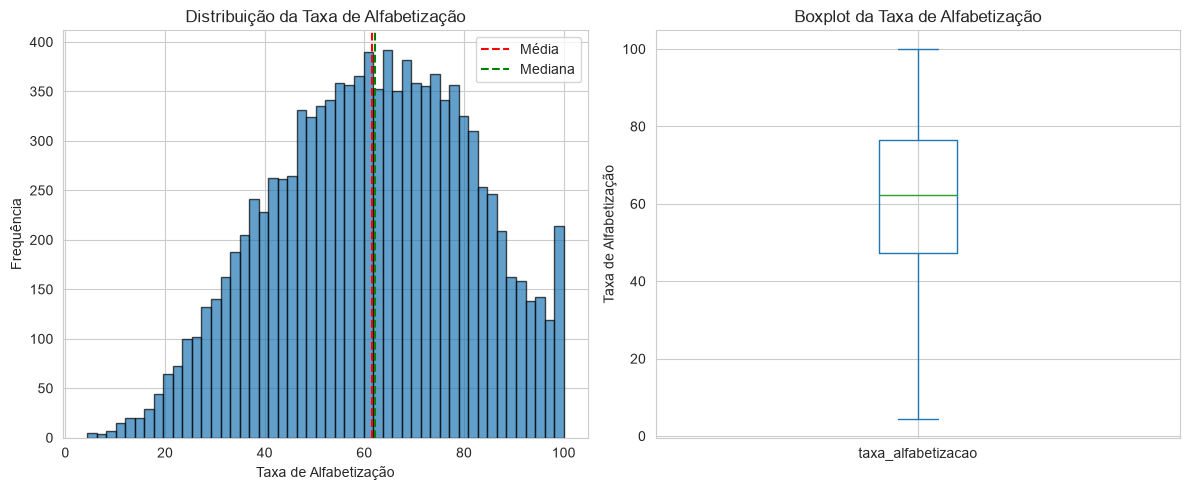

In [77]:
# Análise da taxa de alfabetização
if 'taxa_alfabetizacao' in df.columns:
    print("📊 Estatísticas da Taxa de Alfabetização:")
    print(f"   Média:   {df['taxa_alfabetizacao'].mean():.2f}")
    print(f"   Mediana: {df['taxa_alfabetizacao'].median():.2f}")
    print(f"   Desvio:  {df['taxa_alfabetizacao'].std():.2f}")
    print(f"   Mínimo:  {df['taxa_alfabetizacao'].min():.2f}")
    print(f"   Máximo:  {df['taxa_alfabetizacao'].max():.2f}")
    
    # Histograma
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['taxa_alfabetizacao'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(df['taxa_alfabetizacao'].mean(), color='red', linestyle='--', label='Média')
    plt.axvline(df['taxa_alfabetizacao'].median(), color='green', linestyle='--', label='Mediana')
    plt.xlabel('Taxa de Alfabetização')
    plt.ylabel('Frequência')
    plt.title('Distribuição da Taxa de Alfabetização')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    df['taxa_alfabetizacao'].plot(kind='box')
    plt.ylabel('Taxa de Alfabetização')
    plt.title('Boxplot da Taxa de Alfabetização')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/taxa_alfabetizacao_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Coluna 'taxa_alfabetizacao' não encontrada")

### 4.2 Distribuição de proficiência (níveis 0–8)

São **nove colunas que somam cerca de 100%**: a fatia de alunos em cada degrau da escala. Um gráfico conjunto vale mais que nove histogramas.

**Pergunta:** “Essa composição existe para todos os municípios?”  
**Resposta que o gráfico precisa deixar clara:** **não**. Metade das linhas vem vazia. Mais adiante (e no notebook 03) isso se revela como **“2023 sem níveis, 2024 com níveis”**, não como um furo aleatório de 50% em cada ano. Para o modelo, nível de 2024 **não** pode ser usado para “prever” 2024.


📊 Distribuição de alunos por nível de proficiência
   Colunas: 9
   Linhas COM níveis preenchidos: 5,448 (50.0%)
   Linhas SEM nenhum nível:         5,448 (50.0%)

Percentual de nulos por coluna:
proporcao_aluno_nivel_0    50.0
proporcao_aluno_nivel_1    50.0
proporcao_aluno_nivel_2    50.0
proporcao_aluno_nivel_3    50.0
proporcao_aluno_nivel_4    50.0
proporcao_aluno_nivel_5    50.0
proporcao_aluno_nivel_6    50.0
proporcao_aluno_nivel_7    50.0
proporcao_aluno_nivel_8    50.0

Taxa média COM níveis: 62.80%
Taxa média SEM níveis: 60.28%

Proporção média por nível (só linhas preenchidas):
   Nível 0: 2.20%
   Nível 1: 4.18%
   Nível 2: 7.54%
   Nível 3: 11.06%
   Nível 4: 18.10%
   Nível 5: 24.37%
   Nível 6: 18.76%
   Nível 7: 9.11%
   Nível 8: 4.66%


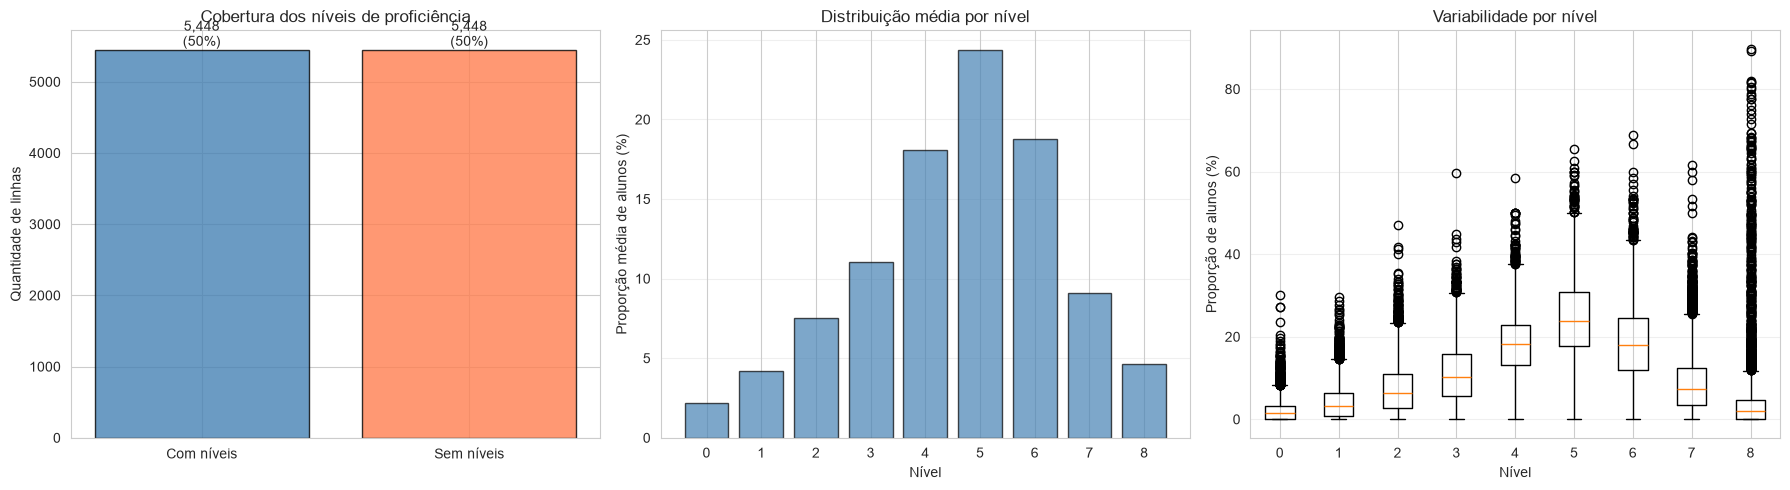

In [78]:
# Análise das proporções de alunos por nível de proficiência
nivel_cols = [col for col in df.columns if col.startswith('proporcao_aluno_nivel_')]
nivel_cols = sorted(nivel_cols, key=lambda c: int(c.split('_')[-1]))

if not nivel_cols:
    print("⚠️  Colunas de nível de proficiência não encontradas")
else:
    nulos_por_col = df[nivel_cols].isna().mean() * 100
    linhas_sem_nivel = df[nivel_cols].isna().all(axis=1)
    linhas_com_nivel = linhas_sem_nivel.eq(False)
    n_sem = int(linhas_sem_nivel.sum())
    n_com = int(linhas_com_nivel.sum())

    print("📊 Distribuição de alunos por nível de proficiência")
    print(f"   Colunas: {len(nivel_cols)}")
    print(f"   Linhas COM níveis preenchidos: {n_com:,} ({n_com / len(df):.1%})")
    print(f"   Linhas SEM nenhum nível:         {n_sem:,} ({n_sem / len(df):.1%})")
    print("\nPercentual de nulos por coluna:")
    print(nulos_por_col.round(1).to_string())

    if 'taxa_alfabetizacao' in df.columns:
        taxa_com = df.loc[linhas_com_nivel, 'taxa_alfabetizacao'].mean()
        taxa_sem = df.loc[linhas_sem_nivel, 'taxa_alfabetizacao'].mean()
        print(f"\nTaxa média COM níveis: {taxa_com:.2f}%")
        print(f"Taxa média SEM níveis: {taxa_sem:.2f}%")

    df_niveis = df.loc[linhas_com_nivel, nivel_cols]
    nivel_medias = df_niveis.mean()
    niveis = [col.split('_')[-1] for col in nivel_cols]

    print("\nProporção média por nível (só linhas preenchidas):")
    for col, value in nivel_medias.items():
        print(f"   Nível {col.split('_')[-1]}: {value:.2f}%")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].bar(['Com níveis', 'Sem níveis'], [n_com, n_sem],
                color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
    axes[0].set_ylabel('Quantidade de linhas')
    axes[0].set_title('Cobertura dos níveis de proficiência')
    for i, v in enumerate([n_com, n_sem]):
        axes[0].text(i, v, f'{v:,}\n({v / len(df):.0%})', ha='center', va='bottom')

    axes[1].bar(niveis, nivel_medias.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Nível')
    axes[1].set_ylabel('Proporção média de alunos (%)')
    axes[1].set_title('Distribuição média por nível')
    axes[1].grid(axis='y', alpha=0.3)

    axes[2].boxplot([df_niveis[col] for col in nivel_cols], tick_labels=niveis)
    axes[2].set_xlabel('Nível')
    axes[2].set_ylabel('Proporção de alunos (%)')
    axes[2].set_title('Variabilidade por nível')
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../reports/figures/proficiency_levels_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


### 4.3 Média de português

**Pergunta:** “Esta nota média conta uma história *diferente* da taxa de alfabetização?”

Se o formato da distribuição for irmão da taxa, a bivariada (seção 5.1) vai confirmar: correlação ≈ 0,93. Em português: **são quase o mesmo termômetro**. Deixar as duas no modelo é contar a mesma notícia duas vezes — e, pior, a notícia *é o resultado*.


📚 Estatísticas da Média de Português:
   Média:   751.63
   Mediana: 750.70
   Desvio:  23.48
   Mínimo:  673.30
   Máximo:  868.46


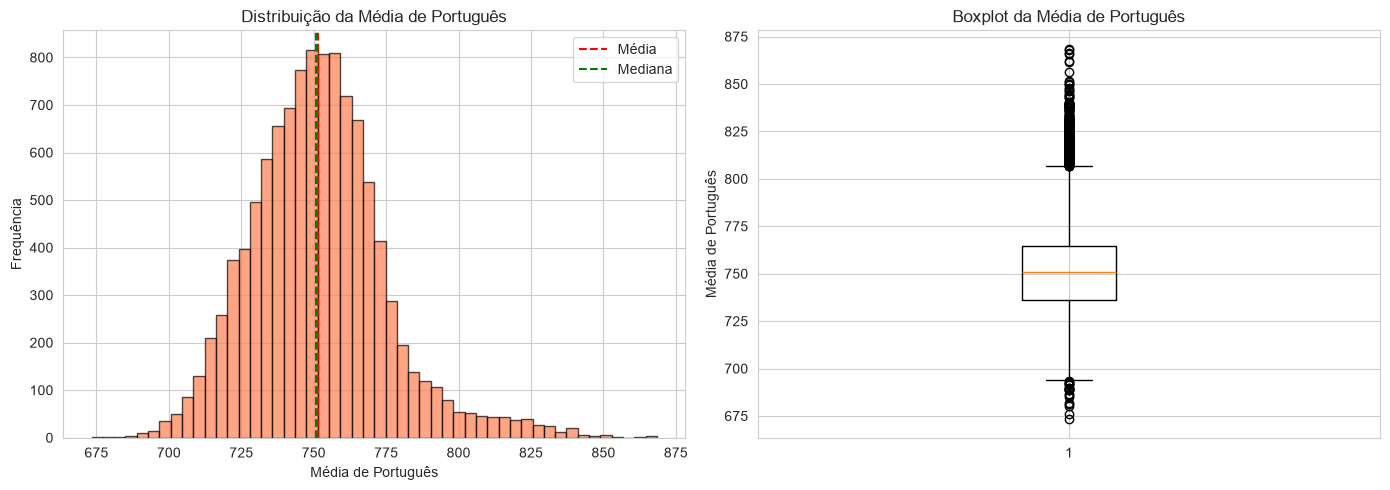

In [79]:
if 'media_portugues' in df.columns:
    print("📚 Estatísticas da Média de Português:")
    print(f"   Média:   {df['media_portugues'].mean():.2f}")
    print(f"   Mediana: {df['media_portugues'].median():.2f}")
    print(f"   Desvio:  {df['media_portugues'].std():.2f}")
    print(f"   Mínimo:  {df['media_portugues'].min():.2f}")
    print(f"   Máximo:  {df['media_portugues'].max():.2f}")
    
    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(df['media_portugues'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[0].axvline(df['media_portugues'].mean(), color='red', linestyle='--', label='Média')
    axes[0].axvline(df['media_portugues'].median(), color='green', linestyle='--', label='Mediana')
    axes[0].set_xlabel('Média de Português')
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Distribuição da Média de Português')
    axes[0].legend()
    
    # Boxplot
    axes[1].boxplot(df['media_portugues'].dropna())
    axes[1].set_ylabel('Média de Português')
    axes[1].set_title('Boxplot da Média de Português')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/media_portugues_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Coluna 'media_portugues' não encontrada")

### 4.4 Taxa base dos municípios

**Pergunta:** “A ‘taxa base’ é um ponto de partida histórico ou é a taxa de agora com outro nome?”

Se o histograma for idêntico ao da `taxa_alfabetizacao`, a correlação na seção 5 vai dar ≈ **1,00**. Aí a decisão é automática: **sai do modelo**. Usar taxa base para prever a taxa é cola.


⚠️  Correlação com taxa_alfabetizacao: 0.9998
   Se for ~1.00, taxa_base é vazamento e não deve ir para o modelo.

🎯 Estatísticas da Taxa Base (Município):
   Média:   61.77%
   Mediana: 62.45%
   Desvio:  19.53
   Mínimo:  4.40%
   Máximo:  100.00%


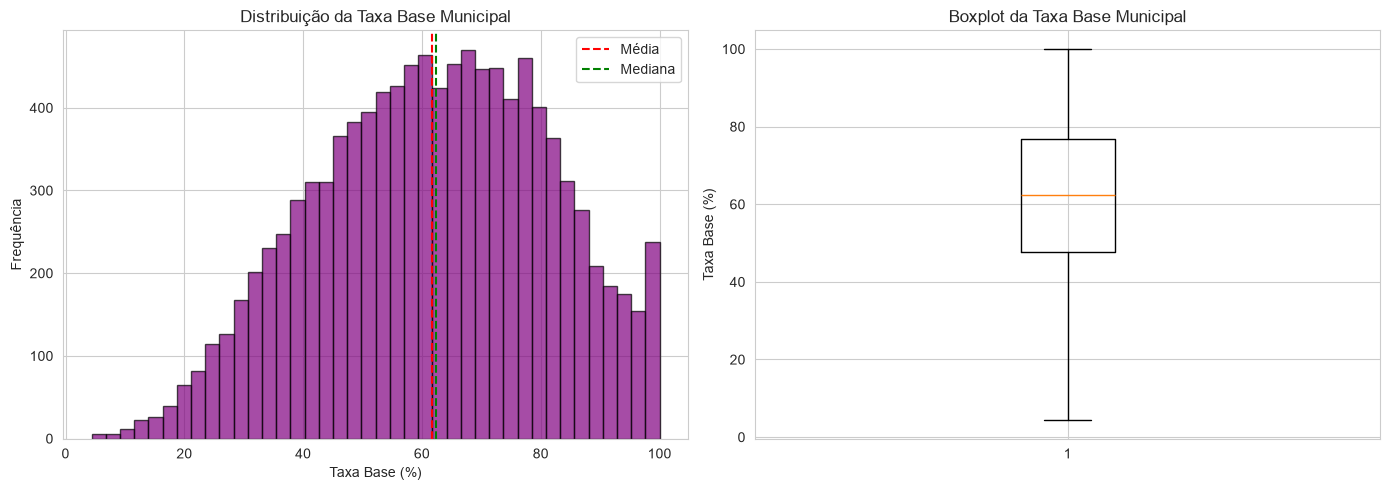

In [80]:
if 'meta_municipio_taxa_base' in df.columns:
    if 'taxa_alfabetizacao' in df.columns:
        corr_base = df[['meta_municipio_taxa_base', 'taxa_alfabetizacao']].corr().iloc[0, 1]
        print(f"⚠️  Correlação com taxa_alfabetizacao: {corr_base:.4f}")
        print("   Se for ~1.00, taxa_base é vazamento e não deve ir para o modelo.\n")
    print("🎯 Estatísticas da Taxa Base (Município):")
    print(f"   Média:   {df['meta_municipio_taxa_base'].mean():.2f}%")
    print(f"   Mediana: {df['meta_municipio_taxa_base'].median():.2f}%")
    print(f"   Desvio:  {df['meta_municipio_taxa_base'].std():.2f}")
    print(f"   Mínimo:  {df['meta_municipio_taxa_base'].min():.2f}%")
    print(f"   Máximo:  {df['meta_municipio_taxa_base'].max():.2f}%")
    
    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(df['meta_municipio_taxa_base'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='purple')
    axes[0].axvline(df['meta_municipio_taxa_base'].mean(), color='red', linestyle='--', label='Média')
    axes[0].axvline(df['meta_municipio_taxa_base'].median(), color='green', linestyle='--', label='Mediana')
    axes[0].set_xlabel('Taxa Base (%)')
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Distribuição da Taxa Base Municipal')
    axes[0].legend()
    
    # Boxplot
    axes[1].boxplot(df['meta_municipio_taxa_base'].dropna())
    axes[1].set_ylabel('Taxa Base (%)')
    axes[1].set_title('Boxplot da Taxa Base Municipal')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/taxa_base_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Coluna 'meta_municipio_taxa_base' não encontrada")

### 4.5 Percentual de participação

**Pergunta:** “Os municípios engajam a mesma fração de alunos na avaliação?”

Participação é **contexto** (quem compareceu), não o percentual alfabetizado. Pode entrar no modelo. Não espere milagre: a relação com a taxa existe, mas é fraca (depois, r ≈ 0,3). Ainda assim é das poucas colunas *honestas*.


📈 Estatísticas do Percentual de Participação:
   Média:   90.43%
   Mediana: 91.20%
   Desvio:  6.27
   Mínimo:  70.00%
   Máximo:  100.00%


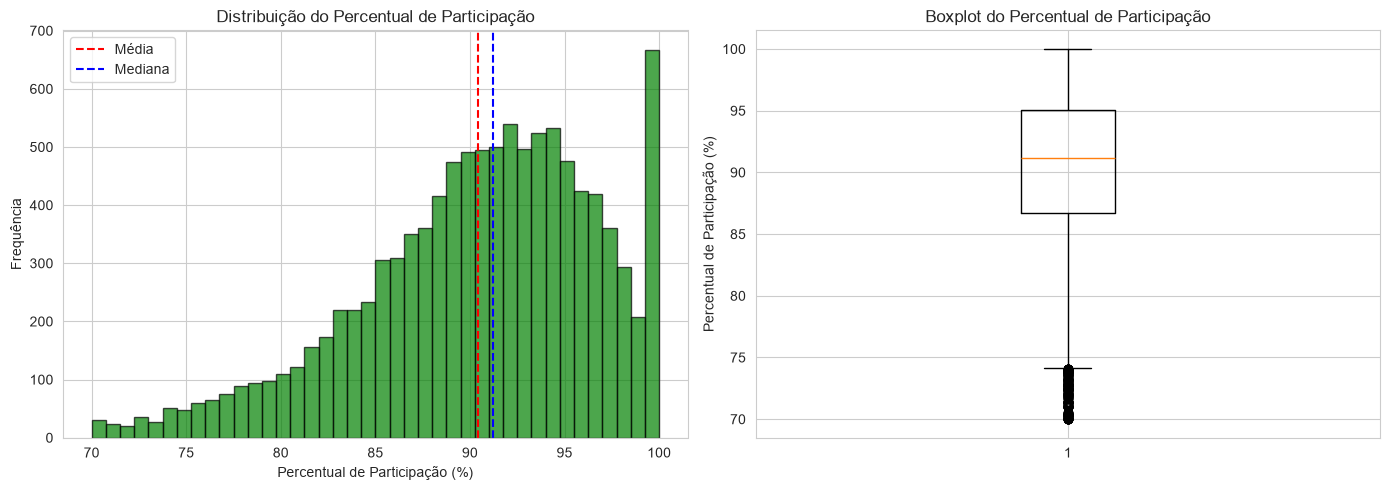

In [81]:
if 'meta_municipio_percentual_participacao' in df.columns:
    print("📈 Estatísticas do Percentual de Participação:")
    print(f"   Média:   {df['meta_municipio_percentual_participacao'].mean():.2f}%")
    print(f"   Mediana: {df['meta_municipio_percentual_participacao'].median():.2f}%")
    print(f"   Desvio:  {df['meta_municipio_percentual_participacao'].std():.2f}")
    print(f"   Mínimo:  {df['meta_municipio_percentual_participacao'].min():.2f}%")
    print(f"   Máximo:  {df['meta_municipio_percentual_participacao'].max():.2f}%")
    
    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(df['meta_municipio_percentual_participacao'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='green')
    axes[0].axvline(df['meta_municipio_percentual_participacao'].mean(), color='red', linestyle='--', label='Média')
    axes[0].axvline(df['meta_municipio_percentual_participacao'].median(), color='blue', linestyle='--', label='Mediana')
    axes[0].set_xlabel('Percentual de Participação (%)')
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Distribuição do Percentual de Participação')
    axes[0].legend()
    
    # Boxplot
    axes[1].boxplot(df['meta_municipio_percentual_participacao'].dropna())
    axes[1].set_ylabel('Percentual de Participação (%)')
    axes[1].set_title('Boxplot do Percentual de Participação')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/percentual_participacao_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Coluna 'meta_municipio_percentual_participacao' não encontrada")

### 4.6 Nível de alfabetização da meta municipal

Isto **não** é o nível 0–8 da turma. É uma **faixa** (rótulo) da própria taxa municipal — tipo “muito baixo / baixo / médio…”. Se as taxas médias de cada faixa subirem em degraus perfeitos (31%, 45%, 55%…), a coluna é a taxa **fatiada**. Também é vazamento: sai do modelo.


🏆 Distribuição do Nível de Alfabetização (Meta):
meta_municipio_nivel_alfabetizacao
0    1605
1    1429
2    1783
3    1898
4    1810
5    2059
Name: count, dtype: int64

Proporção:
meta_municipio_nivel_alfabetizacao
0    14.730176
1    13.114905
2    16.363803
3    17.419236
4    16.611601
5    18.896843
Name: count, dtype: float64


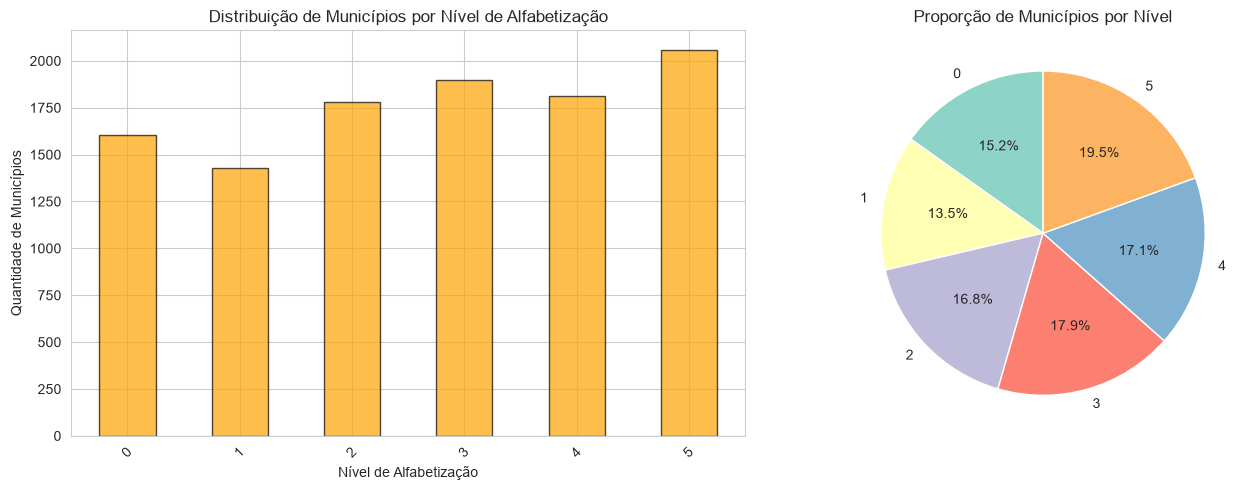

In [82]:
if 'meta_municipio_nivel_alfabetizacao' in df.columns:
    print("🏆 Distribuição do Nível de Alfabetização (Meta):")
    nivel_counts = df['meta_municipio_nivel_alfabetizacao'].value_counts().sort_index()
    print(nivel_counts)
    print(f"\nProporção:")
    print(nivel_counts / len(df) * 100)
    
    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Barras
    nivel_counts.plot(kind='bar', ax=axes[0], color='orange', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Nível de Alfabetização')
    axes[0].set_ylabel('Quantidade de Municípios')
    axes[0].set_title('Distribuição de Municípios por Nível de Alfabetização')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pizza
    nivel_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
    axes[1].set_ylabel('')
    axes[1].set_title('Proporção de Municípios por Nível')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/nivel_alfabetizacao_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Coluna 'meta_municipio_nivel_alfabetizacao' não encontrada")

### 4.7 Geografia: região e UF

**Pergunta:** “A tabela cobre o Brasil de forma parecida, ou tem muito mais linhas de um estado?”

Contar registros é univariada (quantas linhas por região). A **taxa média** por região/UF é bivariada (seção 5.4) — ali aparece Norte/Nordeste abaixo e Sul/Sudeste acima. Geografia **pode** (e deve) entrar no modelo: é contexto, não gabarito. Um modelo que “não usa região” e mesmo assim acerta demais provavelmente usou vazamento.


🗺️  Cobertura geográfica
   Regiões: 5
   UFs:     25
   Municípios distintos: 5500

Registros por região:
regiao
Norte            848
Nordeste        3572
Centro-Oeste     927
Sudeste         3247
Sul             2302

Top 10 UFs por quantidade de registros:
nome_uf
Minas Gerais         1654
São Paulo            1253
Rio Grande do Sul     923
Bahia                 824
Paraná                797
Santa Catarina        582
Goiás                 489
Piauí                 448
Paraíba               444
Maranhão              434


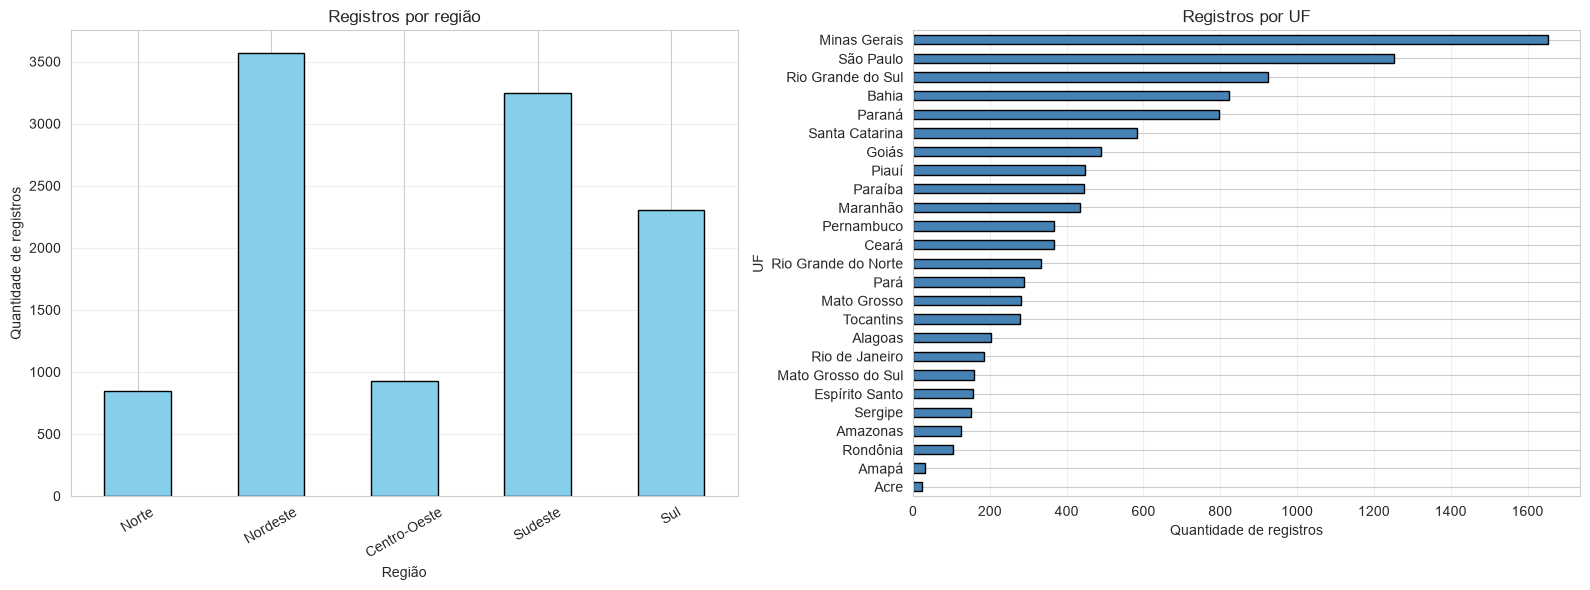

In [83]:
geo_cols = [c for c in ['regiao', 'nome_uf'] if c in df.columns]

if not geo_cols:
    print("⚠️  Colunas geográficas não encontradas")
else:
    print("🗺️  Cobertura geográfica")
    print(f"   Regiões: {df['regiao'].nunique() if 'regiao' in df.columns else 'n/a'}")
    print(f"   UFs:     {df['nome_uf'].nunique() if 'nome_uf' in df.columns else 'n/a'}")
    print(f"   Municípios distintos: {df['id_municipio'].nunique() if 'id_municipio' in df.columns else 'n/a'}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    if 'regiao' in df.columns:
        ordem_regiao = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
        regiao_counts = df['regiao'].value_counts()
        ordem = [r for r in ordem_regiao if r in regiao_counts.index] + [r for r in regiao_counts.index if r not in ordem_regiao]
        regiao_counts = regiao_counts.reindex(ordem)
        print("\nRegistros por região:")
        print(regiao_counts.to_string())
        regiao_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
        axes[0].set_xlabel('Região')
        axes[0].set_ylabel('Quantidade de registros')
        axes[0].set_title('Registros por região')
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].grid(axis='y', alpha=0.3)
    else:
        axes[0].set_visible(False)

    if 'nome_uf' in df.columns:
        uf_counts = df['nome_uf'].value_counts().sort_values()
        print("\nTop 10 UFs por quantidade de registros:")
        print(uf_counts.sort_values(ascending=False).head(10).to_string())
        uf_counts.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
        axes[1].set_xlabel('Quantidade de registros')
        axes[1].set_ylabel('UF')
        axes[1].set_title('Registros por UF')
        axes[1].grid(axis='x', alpha=0.3)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.savefig('../reports/figures/geografia_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


### 4.8 Trajetória das metas 2024–2030

Município, estado e país compartilham o desenho: partir de onde se está e caminhar até cerca de **80% em 2030**. Um gráfico de linhas (média por ano-calendário da meta) substitui 21 histogramas.

**Leitura didática:** a meta de 2024 de cada município **não é um número independente da taxa atual**. Em geral ela é interpolada a partir da taxa base. Por isso, no notebook 03, a família inteira de metas municipais anuais sai do modelo — senão a validação “acerta” 99% lendo a trajetória, que é a taxa disfarçada.


📈 Metas médias de alfabetização (2024–2030)

Município:
2024    62.15
2025    65.28
2026    68.58
2027    71.79
2028    74.81
2029    77.56
2030    80.00
Nulos (%):
2024    4.0
2025    2.2
2026    2.2
2027    2.2
2028    2.2
2029    2.2
2030    2.2

UF:
2024    60.05
2025    63.83
2026    67.51
2027    71.01
2028    74.28
2029    77.28
2030    80.00
Nulos (%):
2024    0.2
2025    0.0
2026    0.0
2027    0.0
2028    0.0
2029    0.0
2030    0.0

Nacional:
2024    59.90
2025    63.77
2026    67.47
2027    70.97
2028    74.23
2029    77.24
2030    80.00
Nulos (%):
2024    0.0
2025    0.0
2026    0.0
2027    0.0
2028    0.0
2029    0.0
2030    0.0

🔒 Colunas constantes (não entram como feature):
   fonte: ['batch']
   meta_municipio_alfabetizacao_2030: [80.0]
   meta_uf_alfabetizacao_2030: [80.0]
   meta_nacional_alfabetizacao_2024: [59.9]
   meta_nacional_alfabetizacao_2025: [63.77]
   meta_nacional_alfabetizacao_2026: [67.47]
   meta_nacional_alfabetizacao_2027: [70.97]
   meta_nacional_a

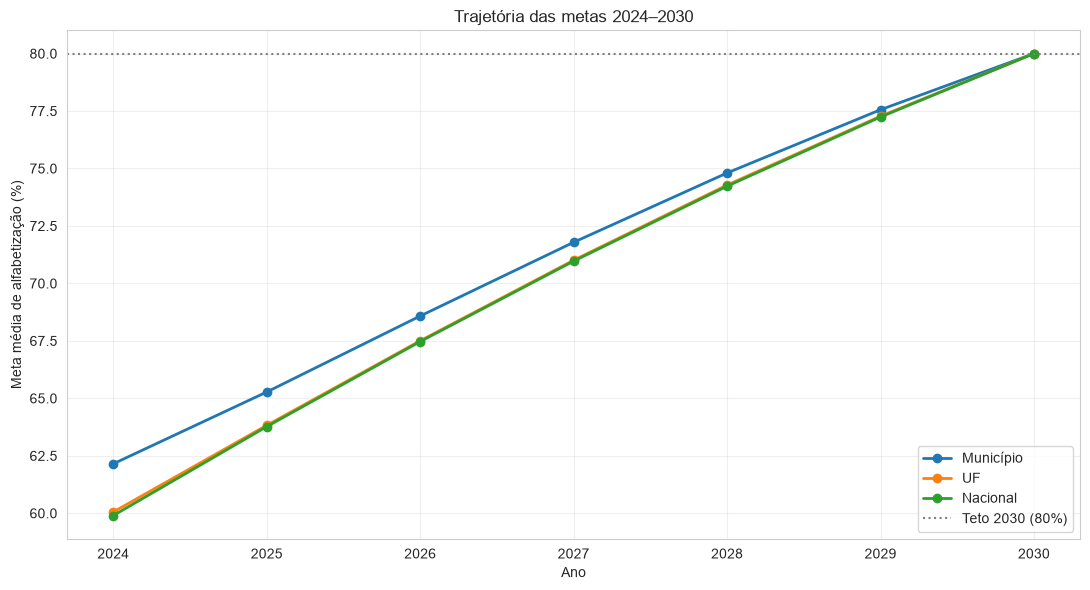

In [84]:
anos = list(range(2024, 2031))
familias = {
    'Município': 'meta_municipio_alfabetizacao',
    'UF': 'meta_uf_alfabetizacao',
    'Nacional': 'meta_nacional_alfabetizacao',
}

print("📈 Metas médias de alfabetização (2024–2030)")
trajetorias = {}
for nome, prefixo in familias.items():
    cols = [f'{prefixo}_{ano}' for ano in anos]
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        print(f"   {nome}: colunas não encontradas")
        continue
    medias = df[existentes].mean()
    medias.index = [int(c.split('_')[-1]) for c in existentes]
    trajetorias[nome] = medias
    nulos = df[existentes].isna().mean() * 100
    print(f"\n{nome}:")
    print(medias.round(2).to_string())
    print("Nulos (%):")
    print(nulos.round(1).rename(lambda c: c.split('_')[-1]).to_string())

# Constantes úteis para o próximo notebook
constantes = []
for col in df.columns:
    nun = df[col].nunique(dropna=True)
    if nun <= 1:
        constantes.append((col, nun, df[col].dropna().unique().tolist()[:3]))
print("\n🔒 Colunas constantes (não entram como feature):")
for col, nun, vals in constantes:
    print(f"   {col}: {vals}")

if trajetorias:
    plt.figure(figsize=(11, 6))
    for nome, serie in trajetorias.items():
        plt.plot(serie.index, serie.values, marker='o', linewidth=2, label=nome)
    plt.axhline(80, color='gray', linestyle=':', linewidth=1.5, label='Teto 2030 (80%)')
    plt.xlabel('Ano')
    plt.ylabel('Meta média de alfabetização (%)')
    plt.title('Trajetória das metas 2024–2030')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/metas_trajetoria_2024_2030.png', dpi=300, bbox_inches='tight')
    plt.show()


## 5. Análise bivariada — quando uma coluna muda, a taxa acompanha?

Pergunta: **esta informação anda junto com a alfabetização municipal, ou é outra história?**

Cruzamos famílias com `taxa_alfabetizacao`. Correlação perto de 1 com a taxa = **cuidado, provavelmente vazamento**. Correlação moderada com geografia ou participação = **candidato honesto**.

| Seção | O que cruza com a taxa | Como olhar |
|---|---|---|
| 5.1 | Média de português | Nuvem de pontos + r |
| 5.2 | Várias numéricas de uma vez | Matriz de cores |
| 5.3 | Meta 2024 | Nuvem: planejamento vs realizado |
| 5.4 | Região e UF | Caixas / barras — desigualdade |
| 5.5 | Níveis 0–8 | Só onde existem; baixos vs altos |
| 5.6 | Participação | Nuvem (relação fraca é ok) |
| 5.7 | Nível-faixa da meta | Caixa por faixa (não use r em rótulo) |

`taxa_base` não ganha nuvem própria: r ≈ 1,00 já encerra o caso.


### 5.1 Taxa vs média de português

Cada ponto é um município-ano. Se os pontos formarem uma reta subindo, as duas medem o mesmo fenômeno. **r ≈ 0,93** = irmãs. Para o modelo: **uma das duas chega**; na dúvida, **nenhuma das duas**, porque ambas são resultado SAEB do mesmo ano do alvo.


📊 Correlação: Taxa de Alfabetização vs Média de Português

Coeficiente de correlação de Pearson: 0.9268


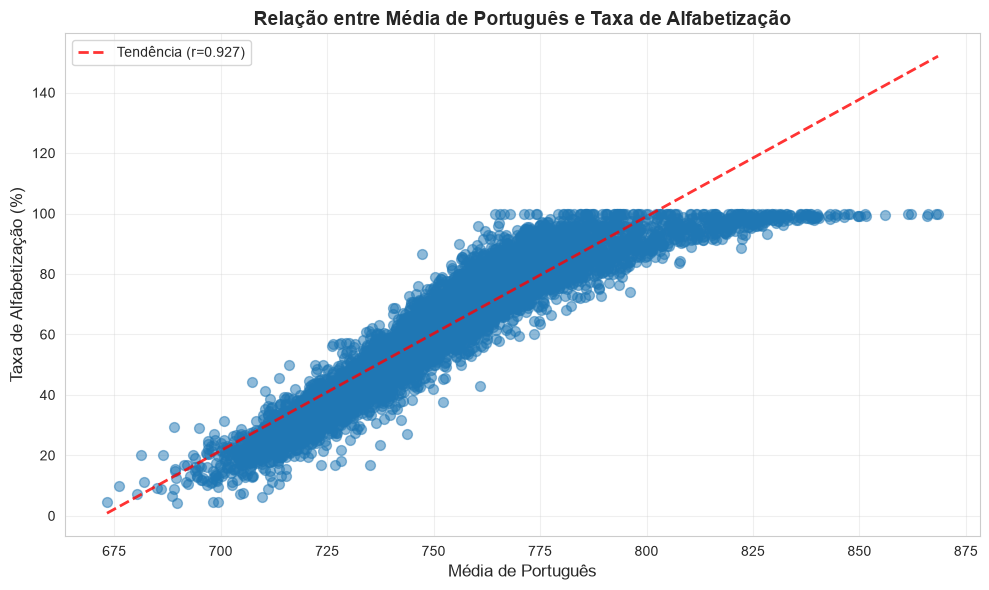

In [85]:
if 'taxa_alfabetizacao' in df.columns and 'media_portugues' in df.columns:
    print("📊 Correlação: Taxa de Alfabetização vs Média de Português")
    
    # Calcular correlação
    corr = df[['taxa_alfabetizacao', 'media_portugues']].corr().iloc[0, 1]
    print(f"\nCoeficiente de correlação de Pearson: {corr:.4f}")
    
    # Scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(df['media_portugues'], df['taxa_alfabetizacao'], alpha=0.5, s=50)
    
    # Linha de tendência
    z = np.polyfit(df['media_portugues'].dropna(), df['taxa_alfabetizacao'].dropna(), 1)
    p = np.poly1d(z)
    plt.plot(df['media_portugues'].sort_values(), p(df['media_portugues'].sort_values()), 
             "r--", alpha=0.8, linewidth=2, label=f'Tendência (r={corr:.3f})')
    
    plt.xlabel('Média de Português', fontsize=12)
    plt.ylabel('Taxa de Alfabetização (%)', fontsize=12)
    plt.title('Relação entre Média de Português e Taxa de Alfabetização', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/corr_portugues_alfabetizacao.png', dpi=300, bbox_inches='tight')
    plt.show()

### 5.2 Matriz de correlação das principais

Mapa de calor: vermelho/azul forte nas células que envolvem a taxa mostram o que é “quase a taxa”. Células fracas com participação ou geografia (quando numérica) mostram sinal mais honesto. Use esta figura no relatório para **justificar o que saiu do modelo**.


🔗 Matriz de Correlação entre Variáveis Principais

Coeficientes de correlação:
                                        taxa_alfabetizacao  media_portugues  \
taxa_alfabetizacao                                1.000000         0.926843   
media_portugues                                   0.926843         1.000000   
meta_municipio_taxa_base                          0.999806         0.926387   
meta_municipio_percentual_participacao            0.289946         0.341433   

                                        meta_municipio_taxa_base  \
taxa_alfabetizacao                                      0.999806   
media_portugues                                         0.926387   
meta_municipio_taxa_base                                1.000000   
meta_municipio_percentual_participacao                  0.289660   

                                        meta_municipio_percentual_participacao  
taxa_alfabetizacao                                                    0.289946  
media_portugues       

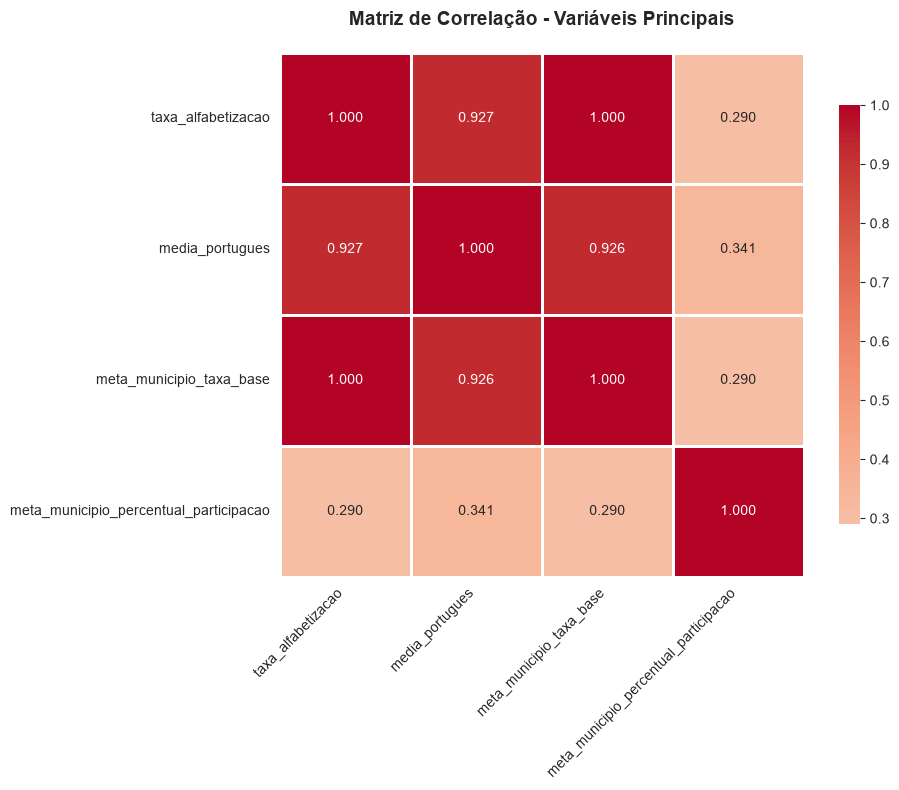

In [86]:
# Selecionar variáveis numéricas principais
main_vars = ['taxa_alfabetizacao', 'media_portugues', 'meta_municipio_taxa_base', 
             'meta_municipio_percentual_participacao']

# Verificar quais estão disponíveis
available_vars = [var for var in main_vars if var in df.columns]

if len(available_vars) >= 2:
    print("🔗 Matriz de Correlação entre Variáveis Principais")
    
    # Calcular correlação
    corr_matrix = df[available_vars].corr()
    print("\nCoeficientes de correlação:")
    print(corr_matrix)
    
    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlação - Variáveis Principais', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../reports/figures/correlation_matrix_main.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Variáveis principais insuficientes para a matriz de correlação")

### 5.3 Meta 2024 vs taxa realizada

**Pergunta de política:** “os municípios estão cumprindo o que foi planejado para 2024?”

Pontos **abaixo** da diagonal (taxa < meta) = ainda não cumpriram. No conjunto misturado dos dois anos, só ~**36%** estão na meta ou acima. Essa porcentagem **não** é a do treino nem a do teste (veja notebook 02): em 2023 a barra de 2024 é dura (~18% cumprem); em 2024 mais da metade cumpre.


🎯 Meta municipal 2024 vs taxa realizada
   Linhas válidas: 10,464
   Acima ou igual à meta 2024: 3,717/10,464 (35.5%)
   Correlação: 0.804


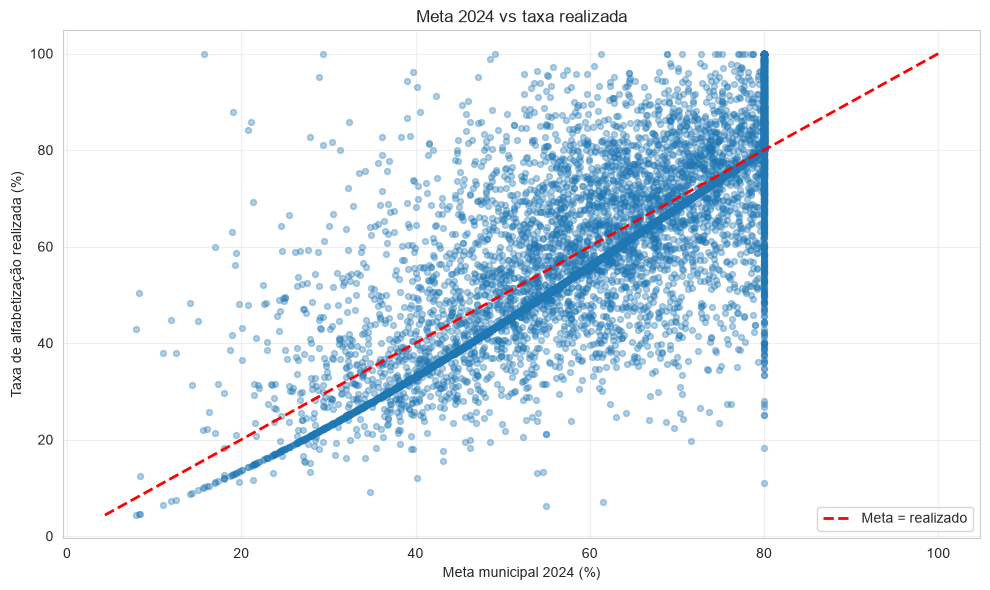

In [87]:
meta_col = 'meta_municipio_alfabetizacao_2024'

if meta_col in df.columns and 'taxa_alfabetizacao' in df.columns:
    df_clean = df[[meta_col, 'taxa_alfabetizacao']].dropna()
    print("🎯 Meta municipal 2024 vs taxa realizada")
    print(f"   Linhas válidas: {len(df_clean):,}")

    reached = (df_clean['taxa_alfabetizacao'] >= df_clean[meta_col]).sum()
    pct = reached / len(df_clean) * 100
    print(f"   Acima ou igual à meta 2024: {reached:,}/{len(df_clean):,} ({pct:.1f}%)")
    print(f"   Correlação: {df_clean[meta_col].corr(df_clean['taxa_alfabetizacao']):.3f}")

    plt.figure(figsize=(10, 6))
    plt.scatter(df_clean[meta_col], df_clean['taxa_alfabetizacao'], alpha=0.35, s=18)
    lims = [
        min(df_clean[meta_col].min(), df_clean['taxa_alfabetizacao'].min()),
        max(df_clean[meta_col].max(), df_clean['taxa_alfabetizacao'].max()),
    ]
    plt.plot(lims, lims, 'r--', linewidth=2, label='Meta = realizado')
    plt.xlabel('Meta municipal 2024 (%)')
    plt.ylabel('Taxa de alfabetização realizada (%)')
    plt.title('Meta 2024 vs taxa realizada')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/target_vs_actual.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f"⚠️  Coluna '{meta_col}' não encontrada")

### 5.4 Taxa por região e por UF

**Esta é a figura de desigualdade.** Norte e Nordeste abaixo da média nacional; Sul, Sudeste e Centro-Oeste acima. UFs como Sergipe, Bahia e Rio Grande do Norte na cauda baixa; Ceará foge do padrão nordestino (muito acima).

Conclusão para o modelo: **região e UF são preditores legítimos de contexto**. Ignorá-los é fingir que alfabetização é igual em todo o mapa. No teste de 2024, só geografia **não** adianta o salto nacional da taxa — mas ainda assim ela entra, porque é o que se saberia sem o gabarito.


🗺️  Taxa de alfabetização por região
              count   mean  median    std    min     max
regiao                                                  
Norte           848  47.66   47.80  16.20   4.56   98.79
Nordeste       3572  54.68   50.90  22.84   4.35  100.00
Sudeste        3247  66.14   65.78  15.03   8.82  100.00
Sul            2302  68.02   70.21  15.74   4.40  100.00
Centro-Oeste    927  68.44   69.44  16.96  12.68  100.00

UFs com menor taxa média:
nome_uf
Sergipe                33.09
Bahia                  37.06
Rio Grande do Norte    39.11
Tocantins              42.41
Acre                   43.50

UFs com maior taxa média:
nome_uf
Minas Gerais      68.96
Paraná            74.95
Espírito Santo    75.85
Goiás             76.44
Ceará             90.14


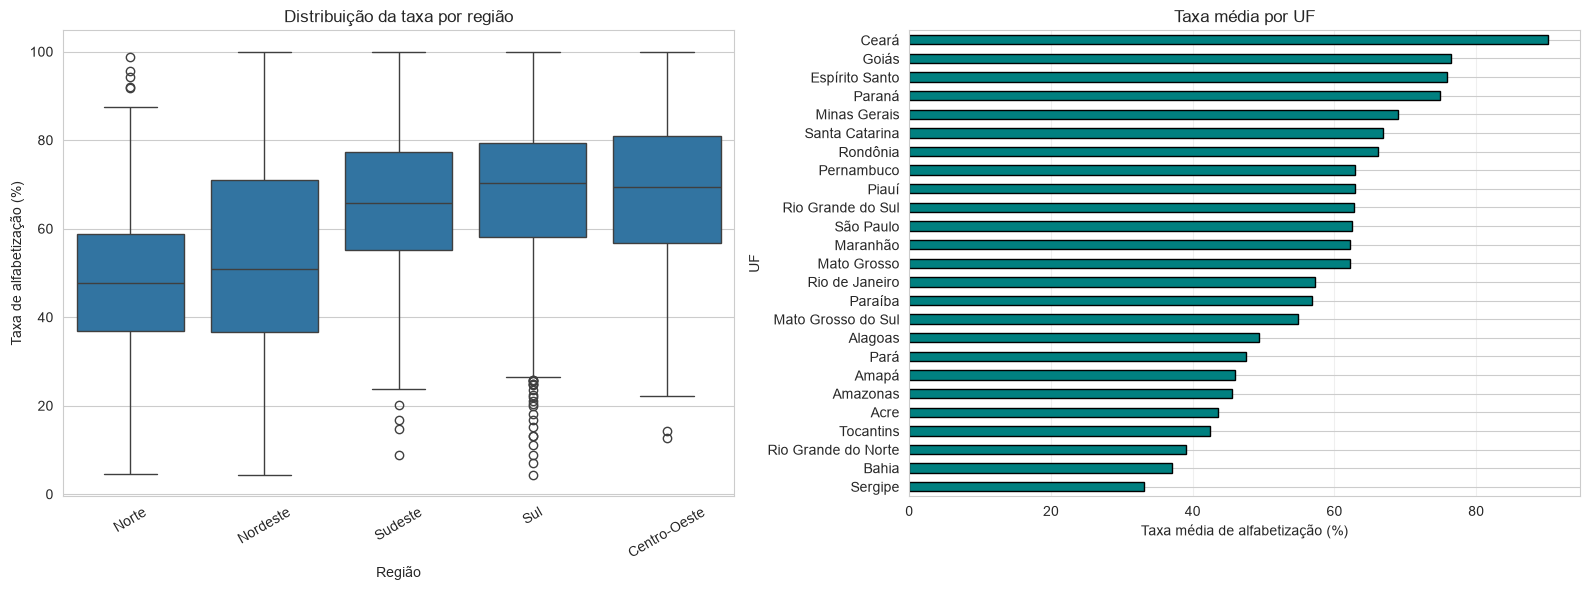

In [88]:
if 'taxa_alfabetizacao' in df.columns and 'regiao' in df.columns:
    print("🗺️  Taxa de alfabetização por região")
    regional = (
        df.groupby('regiao')['taxa_alfabetizacao']
          .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
          .sort_values('mean')
    )
    print(regional.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.boxplot(data=df, x='regiao', y='taxa_alfabetizacao', ax=axes[0], order=regional.index)
    axes[0].set_xlabel('Região')
    axes[0].set_ylabel('Taxa de alfabetização (%)')
    axes[0].set_title('Distribuição da taxa por região')
    axes[0].tick_params(axis='x', rotation=30)

    if 'nome_uf' in df.columns:
        uf_avg = df.groupby('nome_uf')['taxa_alfabetizacao'].mean().sort_values()
        print("\nUFs com menor taxa média:")
        print(uf_avg.head(5).round(2).to_string())
        print("\nUFs com maior taxa média:")
        print(uf_avg.tail(5).round(2).to_string())
        uf_avg.plot(kind='barh', ax=axes[1], color='teal', edgecolor='black')
        axes[1].set_xlabel('Taxa média de alfabetização (%)')
        axes[1].set_ylabel('UF')
        axes[1].set_title('Taxa média por UF')
        axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../reports/figures/literacy_by_region_uf.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Colunas 'regiao' ou 'taxa_alfabetizacao' não encontradas")


### 5.5 Taxa vs níveis de proficiência

Só nas linhas **preenchidas**. Esperado: níveis baixos (0–3) correlacionam **negativo** com a taxa (mais aluno no chão → município pior); níveis altos (6–8), **positivo**. Nível 3 costuma ser o mais negativo (r ≈ −0,80); nível 6, positivo (r ≈ 0,73).

Isso **não** autoriza usar níveis de 2024 para prever a taxa de 2024: é o detalhamento do mesmo resultado. E em 2023 a coluna nem existe.


📊 Taxa vs níveis de proficiência (n=5,448 linhas com níveis preenchidos)
0   -0.567
1   -0.740
2   -0.794
3   -0.800
4   -0.585
5    0.373
6    0.734
7    0.658
8    0.475


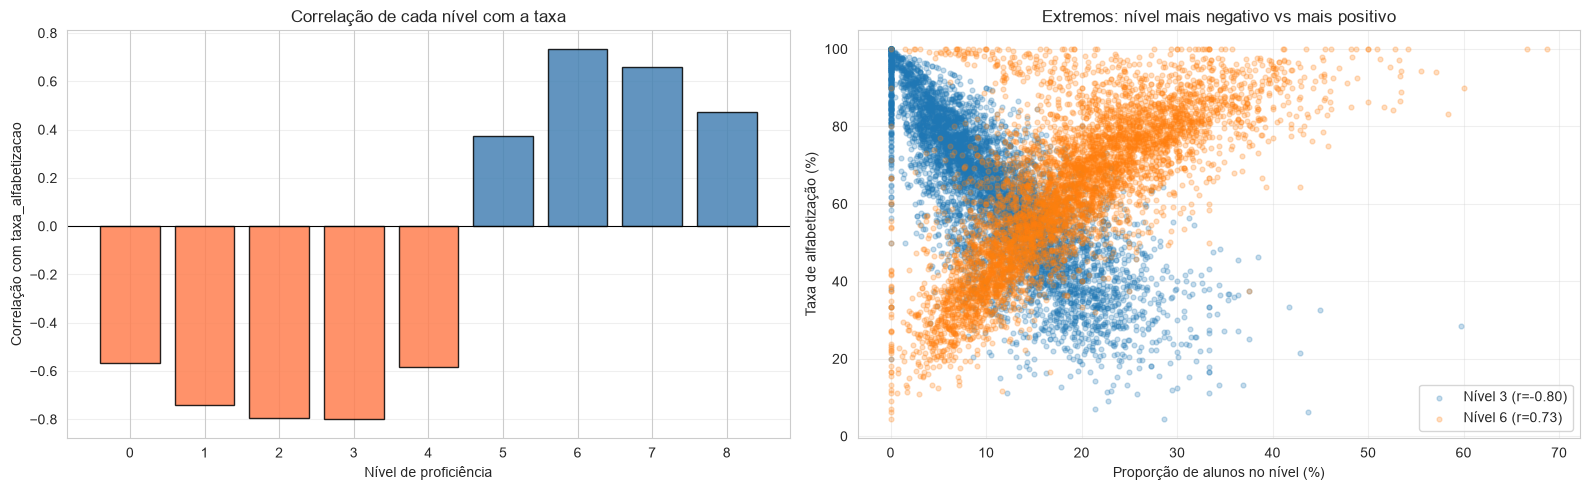

In [89]:
nivel_cols = [c for c in df.columns if c.startswith('proporcao_aluno_nivel_')]
nivel_cols = sorted(nivel_cols, key=lambda c: int(c.split('_')[-1]))

if 'taxa_alfabetizacao' in df.columns and nivel_cols:
    df_niveis = df[nivel_cols + ['taxa_alfabetizacao']].dropna()
    print(f"📊 Taxa vs níveis de proficiência (n={len(df_niveis):,} linhas com níveis preenchidos)")
    corrs = df_niveis[nivel_cols].corrwith(df_niveis['taxa_alfabetizacao'])
    corrs.index = [c.split('_')[-1] for c in corrs.index]
    print(corrs.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    cores = ['coral' if v < 0 else 'steelblue' for v in corrs.values]
    axes[0].bar(corrs.index, corrs.values, color=cores, edgecolor='black', alpha=0.85)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel('Nível de proficiência')
    axes[0].set_ylabel('Correlação com taxa_alfabetizacao')
    axes[0].set_title('Correlação de cada nível com a taxa')
    axes[0].grid(axis='y', alpha=0.3)

    # Scatter do nível mais negativo e do mais positivo
    col_neg = corrs.idxmin()
    col_pos = corrs.idxmax()
    axes[1].scatter(df_niveis[f'proporcao_aluno_nivel_{col_neg}'], df_niveis['taxa_alfabetizacao'],
                    alpha=0.25, s=12, label=f'Nível {col_neg} (r={corrs[col_neg]:.2f})')
    axes[1].scatter(df_niveis[f'proporcao_aluno_nivel_{col_pos}'], df_niveis['taxa_alfabetizacao'],
                    alpha=0.25, s=12, label=f'Nível {col_pos} (r={corrs[col_pos]:.2f})')
    axes[1].set_xlabel('Proporção de alunos no nível (%)')
    axes[1].set_ylabel('Taxa de alfabetização (%)')
    axes[1].set_title('Extremos: nível mais negativo vs mais positivo')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('../reports/figures/taxa_vs_niveis_proficiencia.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Colunas de nível ou taxa não encontradas")


### 5.6 Taxa vs participação

Nuvem mais “espalhada”. r na casa de **0,3**: municípios que levam mais alunos à prova tendem a ter taxa um pouco maior, mas há muita exceção. É das poucas relações **fracas e honestas**. Vale manter; não vale vender como “o” preditor.


📈 Taxa vs participação (n=10,584)
   Correlação de Pearson: 0.290
   Relação fraca: participação não substitui desempenho.


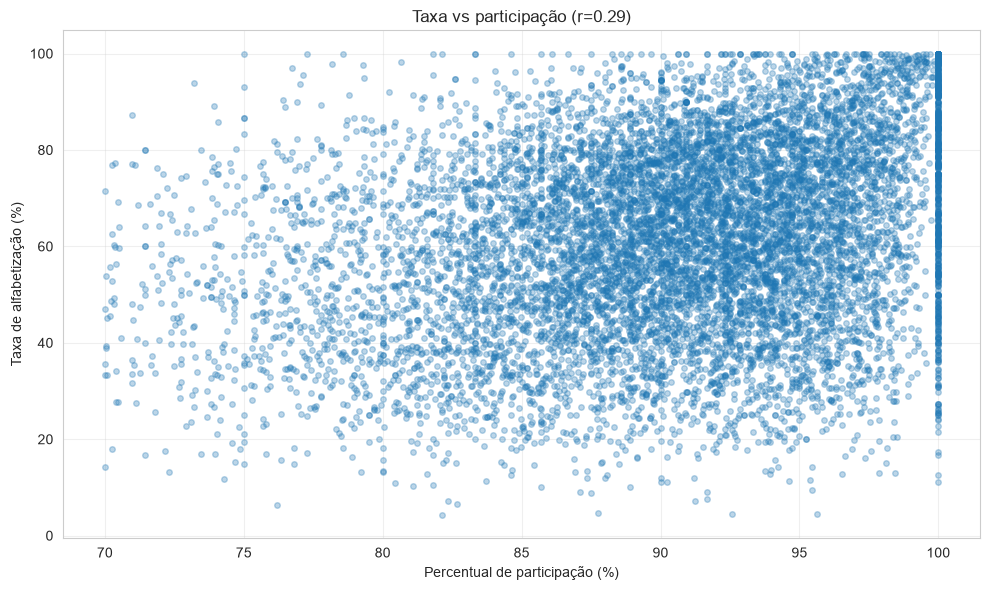

In [90]:
part_col = 'meta_municipio_percentual_participacao'
if 'taxa_alfabetizacao' in df.columns and part_col in df.columns:
    df_part = df[['taxa_alfabetizacao', part_col]].dropna()
    corr = df_part['taxa_alfabetizacao'].corr(df_part[part_col])
    print(f"📈 Taxa vs participação (n={len(df_part):,})")
    print(f"   Correlação de Pearson: {corr:.3f}")
    print("   Relação fraca: participação não substitui desempenho.")

    plt.figure(figsize=(10, 6))
    plt.scatter(df_part[part_col], df_part['taxa_alfabetizacao'], alpha=0.3, s=16)
    plt.xlabel('Percentual de participação (%)')
    plt.ylabel('Taxa de alfabetização (%)')
    plt.title(f'Taxa vs participação (r={corr:.2f})')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/taxa_vs_participacao.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Coluna de participação não encontrada")


### 5.7 Taxa vs nível (faixa) da meta municipal

Como a coluna é **rótulo** (baixo, médio, alto…), não se calcula r. O boxplot da taxa em cada faixa, se subir em degraus, prova que o rótulo **foi cortado da própria taxa**. Sai do modelo, igual à `taxa_base`.


🏷️  Taxa por nível da meta municipal
                                    count   mean  median   std
meta_municipio_nivel_alfabetizacao                            
0                                    1605  30.77   32.32  7.10
1                                    1429  45.30   45.45  2.87
2                                    1783  55.14   55.18  3.01
3                                    1898  65.01   65.00  2.92
4                                    1810  74.95   75.00  2.88
5                                    2059  88.57   87.39  6.10

Se a média sobe de forma quase linear com o nível, essa coluna
pode ser só um recorte da própria taxa — risco de vazamento no notebook 02.


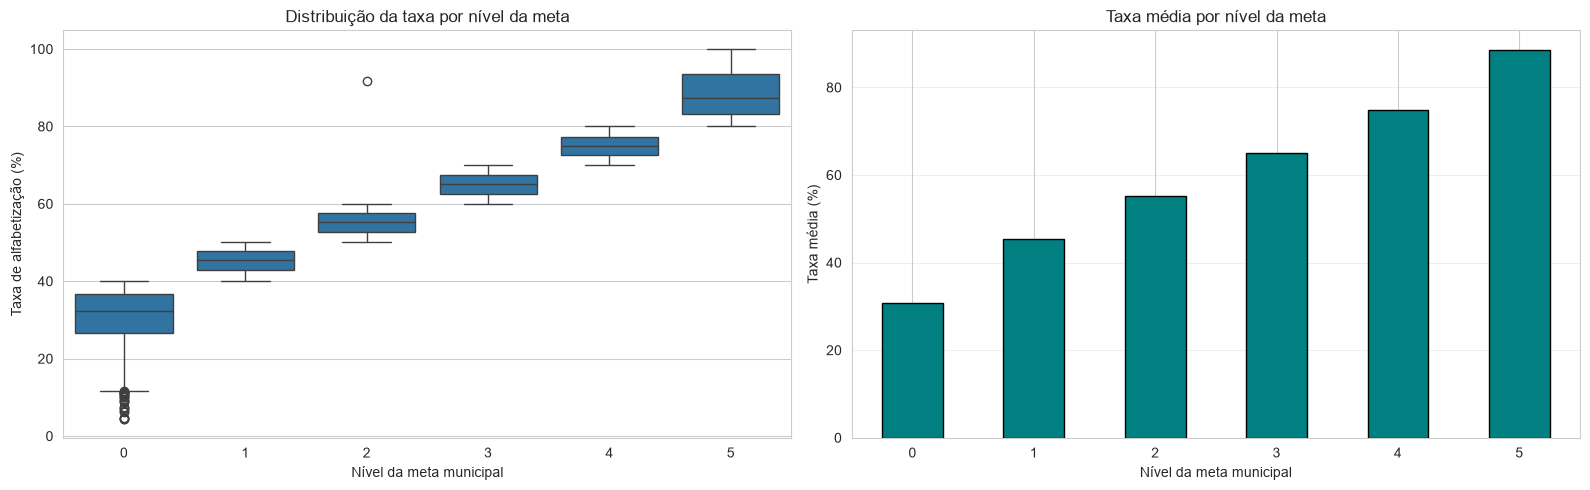

In [91]:
nivel_meta = 'meta_municipio_nivel_alfabetizacao'
if 'taxa_alfabetizacao' in df.columns and nivel_meta in df.columns:
    df_nm = df[[nivel_meta, 'taxa_alfabetizacao']].dropna()
    stats = (
        df_nm.groupby(nivel_meta)['taxa_alfabetizacao']
             .agg(['count', 'mean', 'median', 'std'])
             .sort_index()
    )
    print("🏷️  Taxa por nível da meta municipal")
    print(stats.round(2))
    print("\nSe a média sobe de forma quase linear com o nível, essa coluna")
    print("pode ser só um recorte da própria taxa — risco de vazamento no notebook 02.")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.boxplot(data=df_nm, x=nivel_meta, y='taxa_alfabetizacao', ax=axes[0], order=stats.index)
    axes[0].set_xlabel('Nível da meta municipal')
    axes[0].set_ylabel('Taxa de alfabetização (%)')
    axes[0].set_title('Distribuição da taxa por nível da meta')

    stats['mean'].plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
    axes[1].set_xlabel('Nível da meta municipal')
    axes[1].set_ylabel('Taxa média (%)')
    axes[1].set_title('Taxa média por nível da meta')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../reports/figures/taxa_vs_nivel_meta.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Coluna de nível da meta não encontrada")


## 6. Correlações — visão ampla

Aqui o código lista pares numéricos demais para caber num único heatmap “bonito”. Use para **caçar** qualquer coluna que ainda tenha r ≈ 1 com a taxa e não tenha sido citada. Se aparecer, ela também é candidata a vazamento.


📊 Calculando correlações entre 29 variáveis numéricas...


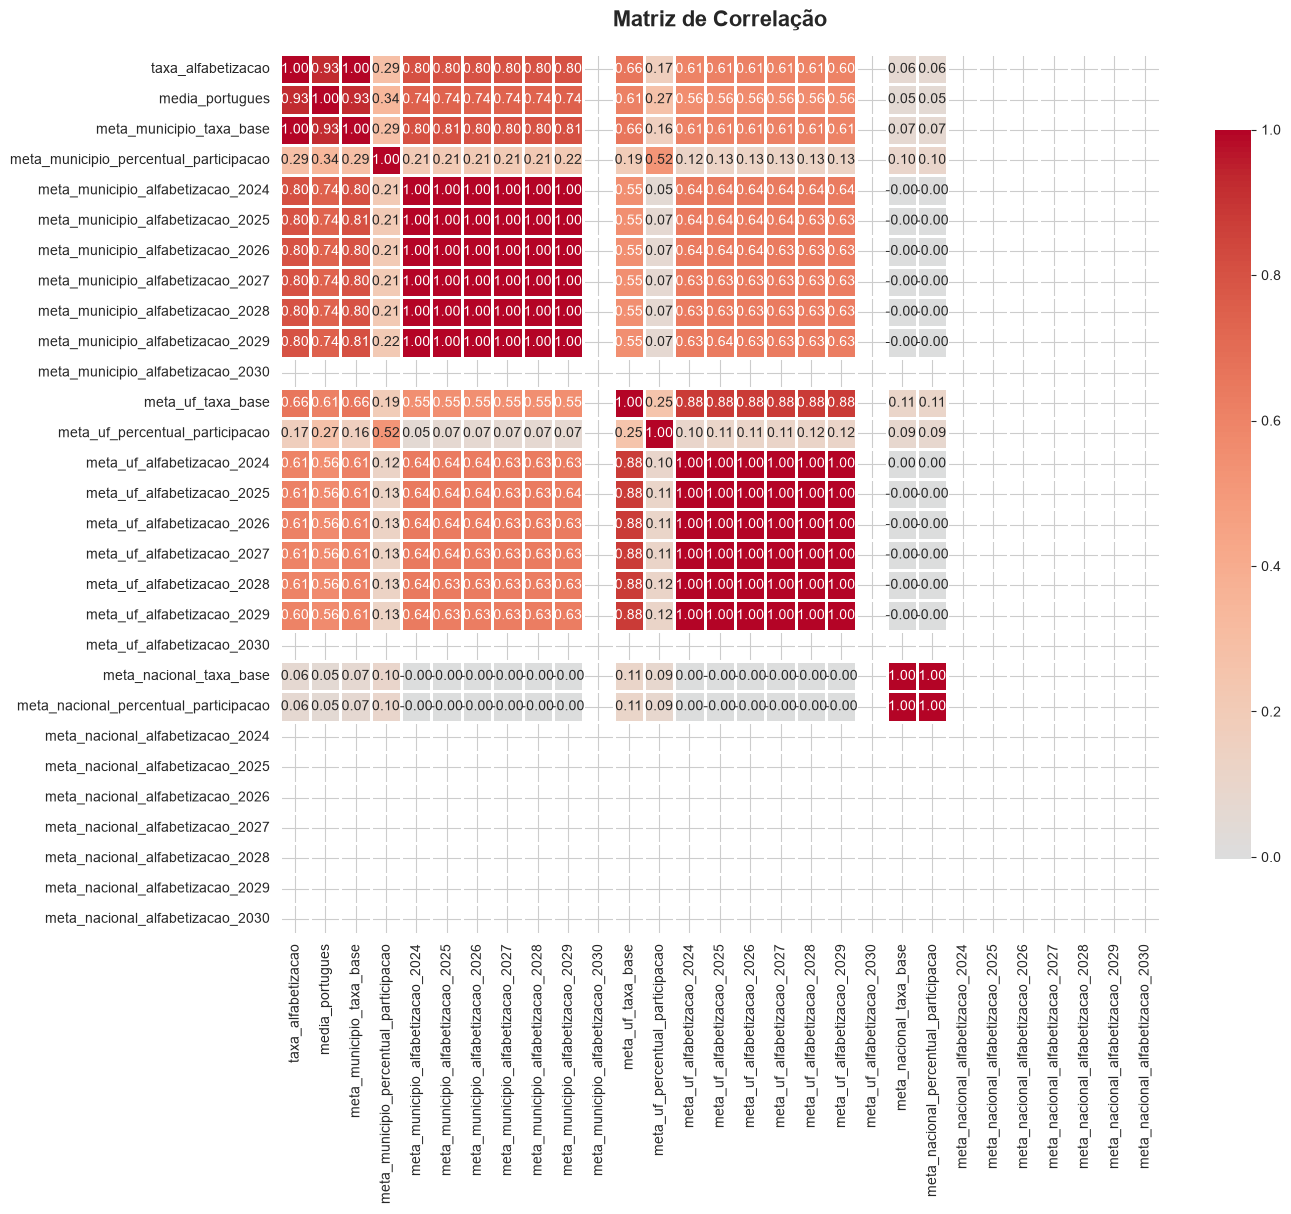

In [92]:
# Selecionar apenas colunas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"📊 Calculando correlações entre {len(numeric_cols)} variáveis numéricas...")

# Calcular correlação
correlation = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Valores faltantes — buraco é informação

**Pergunta:** “o vazio é acaso ou é um recorte (um ano, uma região, um tipo de município)?”

Barras altas nos `proporcao_aluno_nivel_*` (~50%) **não** são 50% aleatório em cada ano: o notebook 03 mostra **0% em 2023 e 100% em 2024**. Tratar isso como “média geral de nulo” esconderia que o campo é um produto **só do segundo ano**.

Metas nacionais constantes / às vezes nulas não ajudam o modelo municipal. IDs não devem ter nulo; se tiverem, a linha está quebrada.

**Regra:** nulo de **resultado do mesmo ano** não se “completa” para prever esse resultado. Nulo de **contexto** pode ser marcado com um indicador (`tem_nivel`) e imputado com cuidado, só no treino.


⚠️  Valores Faltantes Encontrados:
                                        Count  Percentage
proporcao_aluno_nivel_0                  5448   50.000000
proporcao_aluno_nivel_2                  5448   50.000000
proporcao_aluno_nivel_3                  5448   50.000000
proporcao_aluno_nivel_4                  5448   50.000000
proporcao_aluno_nivel_5                  5448   50.000000
proporcao_aluno_nivel_6                  5448   50.000000
proporcao_aluno_nivel_7                  5448   50.000000
proporcao_aluno_nivel_8                  5448   50.000000
proporcao_aluno_nivel_1                  5448   50.000000
meta_municipio_alfabetizacao_2024         432    3.964758
meta_municipio_nivel_alfabetizacao        312    2.863436
meta_municipio_percentual_participacao    312    2.863436
meta_municipio_taxa_base                  312    2.863436
meta_municipio_alfabetizacao_2025         242    2.220999
meta_municipio_alfabetizacao_2026         242    2.220999
meta_municipio_alfabetizacao_2027    

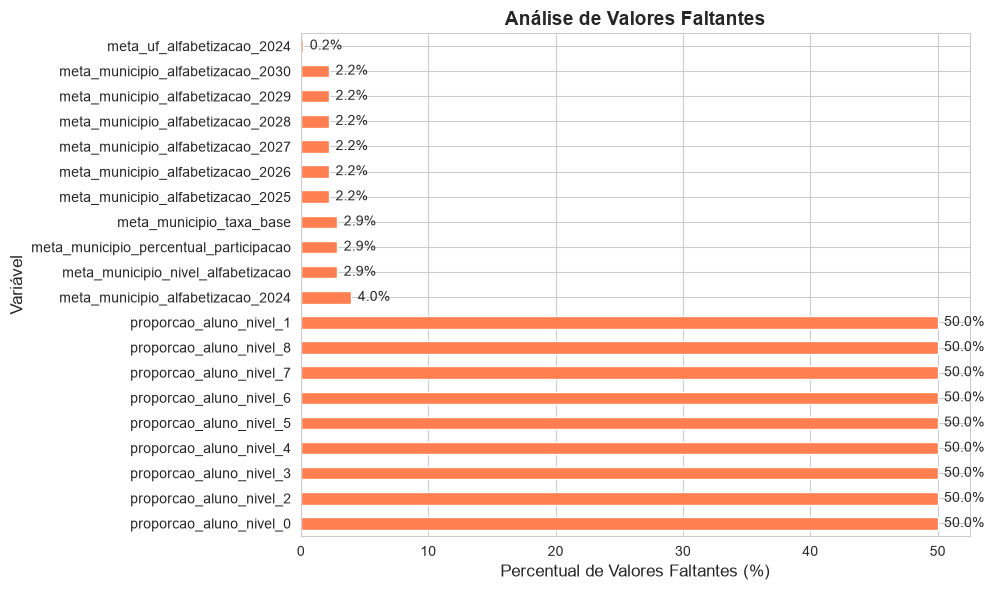

In [93]:
# Calcular valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("⚠️  Valores Faltantes Encontrados:")
    
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Count': missing,
        'Percentage': missing_pct
    })
    
    print(missing_df)
    
    # Gráfico
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='barh', color='coral')
    plt.xlabel('Percentual de Valores Faltantes (%)', fontsize=12)
    plt.ylabel('Variável', fontsize=12)
    plt.title('Análise de Valores Faltantes', fontsize=14, fontweight='bold')
    
    # Adicionar valores nas barras
    for idx, value in enumerate(missing_df['Percentage'].values):
        plt.text(value + 0.5, idx, f'{value:.1f}%', va='center')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("✅ Não há valores faltantes no dataset!")

## 8. Insights e conclusões — o que isso muda no modelo

Esta seção é o **contrato** com os notebooks 02 e 03. Se o relatório precisar de uma página só, é esta.

### 8.0 Para quem não é da área (resumo executivo)

- Não dá para treinar “aluno alfabetizado / não” **neste** arquivo: não há aluno.
- Dá para perguntar se o **município** já atingiu a **meta de 2024**.
- Várias colunas bonitas (taxa base, média de português, “nível” da meta, metas anuais interpoladas) **são a própria taxa**. Entrar com elas no modelo é cola.
- O Brasil desta amostra é **desigual**: Norte/Nordeste abaixo, Sul/Sudeste/Centro-Oeste acima.
- Os notebooks seguintes treinam em **2023** e cobram em **2024** (prova no futuro). O mesmo município nos dois anos **não** é erro — é o teste temporal. Sortear linhas misturando os anos **seria** erro.
- Com as colunas honestas, o modelo de 2024 fica **fraco**. Isso é conclusão, não defeito de código.

---
## 8. Insights e Conclusões

Esta seção resume o que o EDA mostrou e o que isso muda no modelo da Fase 3.

### 8.1 Qual é a unidade do dado?

O Silver `indicador_alfabetizacao` tem **10.896 linhas**, **5.500 municípios** e **25 UFs**. Quase todo município aparece **duas vezes** (dois anos). A chave real é **município + ano**, rede municipal — não aluno.

Não há `id_aluno`, nota individual nem o corte de 743 pontos por criança. A `taxa_alfabetizacao` já é o **percentual de alunos do município** que passaram no Indicador Criança Alfabetizada. Com este Silver, o modelo da Fase 3 classifica o **município** (ou um status derivado da taxa), não o indivíduo.

`fonte` é constante (`batch`). IDs (`id_municipio`, `nome_municipio`) não são feature.

### 8.2 Como está a alfabetização

- A taxa média fica perto de **62%** (mín. ~4%, máx. 100%).
- **Norte (~48%) e Nordeste (~55%)** abaixo da média; **Sul, Sudeste e Centro-Oeste (~66–68%)** acima.
- Piores UFs na amostra: **Sergipe, Bahia, Rio Grande do Norte**. Ceará foge do padrão nordestino (~90%).
- Só **~36%** das linhas estão na meta municipal de 2024 ou acima. Há gap entre planejamento e realizado.

Conclusão: a desigualdade é regional e estadual. Um modelo que ignore `regiao` e `nome_uf` vai errar de forma sistemática no Norte/Nordeste.

### 8.3 O que parece preditor, mas é vazamento

Estas colunas descrevem o **resultado**, não o contexto. Se entrarem no modelo, a métrica sobe e a previsão não serve.

| Coluna | Evidência no EDA | Decisão |
|---|---|---|
| `meta_municipio_taxa_base` | r ≈ **1,00** com a taxa | Fora |
| `media_portugues` | r ≈ **0,93** | Fora (ou só com justificativa explícita) |
| `meta_municipio_nivel_alfabetizacao` | médias em degraus ≈ 31% → 45% → 55% → 65% → 75% → 89% | Fora — é a taxa fatiada |

O corte **743** é da escala SAEB do aluno. Aplicar 743 em cima da taxa (0–100%) está errado.

### 8.4 O que de fato informa

- **Níveis 0–8:** onde existem, níveis baixos andam com taxa baixa (nível 3: r ≈ −0,80) e níveis altos com taxa alta (nível 6: r ≈ 0,73). Estão **vazios em 50%** das linhas; o nulo é falta de cobertura, não um recorte óbvio de desempenho. Precisam de flag de missing.
- **Participação:** r ≈ **0,29**. Município que participa mais não é automaticamente o mais alfabetizado. Feature auxiliar, não o núcleo.
- **Metas 2024–2030:** município, UF e nacional sobem juntos até **80% em 2030**. Isso é trajetória de política, não medição atual. Não usar a meta do mesmo ano como se fosse o resultado.

### 8.5 Hipóteses para o notebook 02

1. Target binário no **município**, por exemplo `1` se a taxa ≥ meta 2024 (ou outro limiar justificado) — alinhado ao enunciado “alfabetizado / não alfabetizado” sem fingir linha de aluno.
2. Features candidatas: geografia (`regiao`, `nome_uf`), participação, níveis 0–8 + indicador de nulo. Fora: IDs, `fonte`, `taxa_base`, nível da meta, `media_portugues` crua.
3. Split **temporal** no notebook 02: treino = 2023, teste = 2024. O mesmo município **pode** estar nos dois (backtest). O que não pode é sortear linhas misturando os anos, nem usar a taxa (ou a trajetória da meta) de 2024 para “prever” 2024.
4. Região e UF são contexto legítimo. Se a importância for só de `taxa_base` / metas 2025–2029 / média de português, houve vazamento.
5. Níveis 0–8 **não** entram no backtest 2023→2024: não existem em 2023 e em 2024 são o detalhe do resultado.

### 8.6 Limitações

- Sem microdado do SAEB, não há modelo por indivíduo neste projeto.
- Metade das linhas não tem distribuição por nível de proficiência.
- A duplicidade município–ano precisa ser tratada antes da validação, senão a métrica fica otimista.

---

**Próximo passo:** Notebook 02 — criar o alvo municipal (taxa ≥ meta 2024), remover vazamentos e cortar 2023/2024.
